In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from experiments import setup_publication_style

RESULTS_DIR = Path("../../results/paper/experiments")
OUTPUT_DIR  = Path("../../results/paper/experiments/plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Each entry defines one series to load.
# player_idx / opp_idx select which rows in the CSV to aggregate.
SERIES = [
    {"label": "POMDP Self-play", "exp": 1, "player_idx": 0, "opp_idx": 0},
    {"label": "MDP Self-play",   "exp": 2, "player_idx": 0, "opp_idx": 0},
    {"label": "POMDP vs TFT",   "exp": 3, "player_idx": 0, "opp_idx": 1},
    {"label": "POMDP vs WSLS",  "exp": 3, "player_idx": 0, "opp_idx": 2},
    {"label": "MDP vs TFT",     "exp": 4, "player_idx": 0, "opp_idx": 1},
    {"label": "MDP vs WSLS",    "exp": 4, "player_idx": 0, "opp_idx": 2},
]

setup_publication_style(use_latex=False, font_size=10)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

print(f"Results directory : {RESULTS_DIR.resolve()}")
print(f"Output directory  : {OUTPUT_DIR.resolve()}")

Results directory : /home/kivalm/code/AIFNIPD/results/paper/experiments
Output directory  : /home/kivalm/code/AIFNIPD/results/paper/experiments/plots


In [13]:
def load_metrics(csv_file: Path, player_idx: int, opp_idx: int) -> dict:
    """Return score and CC rate for a specific player/opponent pair from one CSV.

    score   = mean Score across matching rows (handles duplicate self-play rows)
    cc_rate = total CC count / total Turns across matching rows
    """
    data = pd.read_csv(csv_file)
    mask = (data["Player index"] == player_idx) & (data["Opponent index"] == opp_idx)
    rows = data.loc[mask]
    if len(rows) == 0:
        return {"score": float("nan"), "cc_rate": float("nan")}
    score   = float(rows["Score"].mean())
    total_turns = rows["Turns"].sum()
    cc_rate = float(rows["CC count"].sum() / total_turns) if total_turns > 0 else float("nan")
    return {"score": score, "cc_rate": cc_rate}


rows = []

for series in SERIES:
    label      = series["label"]
    exp_dir    = RESULTS_DIR / str(series["exp"])
    player_idx = series["player_idx"]
    opp_idx    = series["opp_idx"]

    # Derive grouping columns from the label
    formulation = "POMDP" if "POMDP" in label else "MDP"
    if "Self-play" in label:
        matchup = "Self-play"
    elif "TFT" in label:
        matchup = "vs TFT"
    else:
        matchup = "vs WSLS"

    for rep_dir in sorted(exp_dir.glob("repetition_*")):
        rep = int(rep_dir.name.split("_")[1])
        for csv_file in sorted(rep_dir.glob("*.csv")):
            noise = float(csv_file.stem)
            m = load_metrics(csv_file, player_idx, opp_idx)
            if np.isfinite(m["score"]):
                rows.append({
                    "series":      label,
                    "formulation": formulation,
                    "matchup":     matchup,
                    "noise_level": noise,
                    "repetition":  rep,
                    "score":       m["score"],
                    "cc_rate":     m["cc_rate"],
                })

df = pd.DataFrame(rows)
# Use a categorical noise level so boxplots space evenly
df["noise_label"] = df["noise_level"].apply(lambda x: f"{x:.2f}")

print(f"Loaded {len(df)} rows")
print(f"Noise levels : {sorted(df['noise_level'].unique())}")
print(f"Series       : {df['series'].unique().tolist()}")
df.head()

Loaded 1080 rows
Noise levels : [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25)]
Series       : ['POMDP Self-play', 'MDP Self-play', 'POMDP vs TFT', 'POMDP vs WSLS', 'MDP vs TFT', 'MDP vs WSLS']


,series,formulation,matchup,noise_level,repetition,score,cc_rate,noise_label
0,POMDP Self-play,POMDP,Self-play,0.00,0,14848.0,0.9848,0.00
1,POMDP Self-play,POMDP,Self-play,0.05,0,14586.5,0.8814,0.05
2,POMDP Self-play,POMDP,Self-play,0.10,0,12453.0,0.4060,0.10
3,POMDP Self-play,POMDP,Self-play,0.15,0,8552.5,0.0758,0.15
4,POMDP Self-play,POMDP,Self-play,0.20,0,11160.0,0.2560,0.20


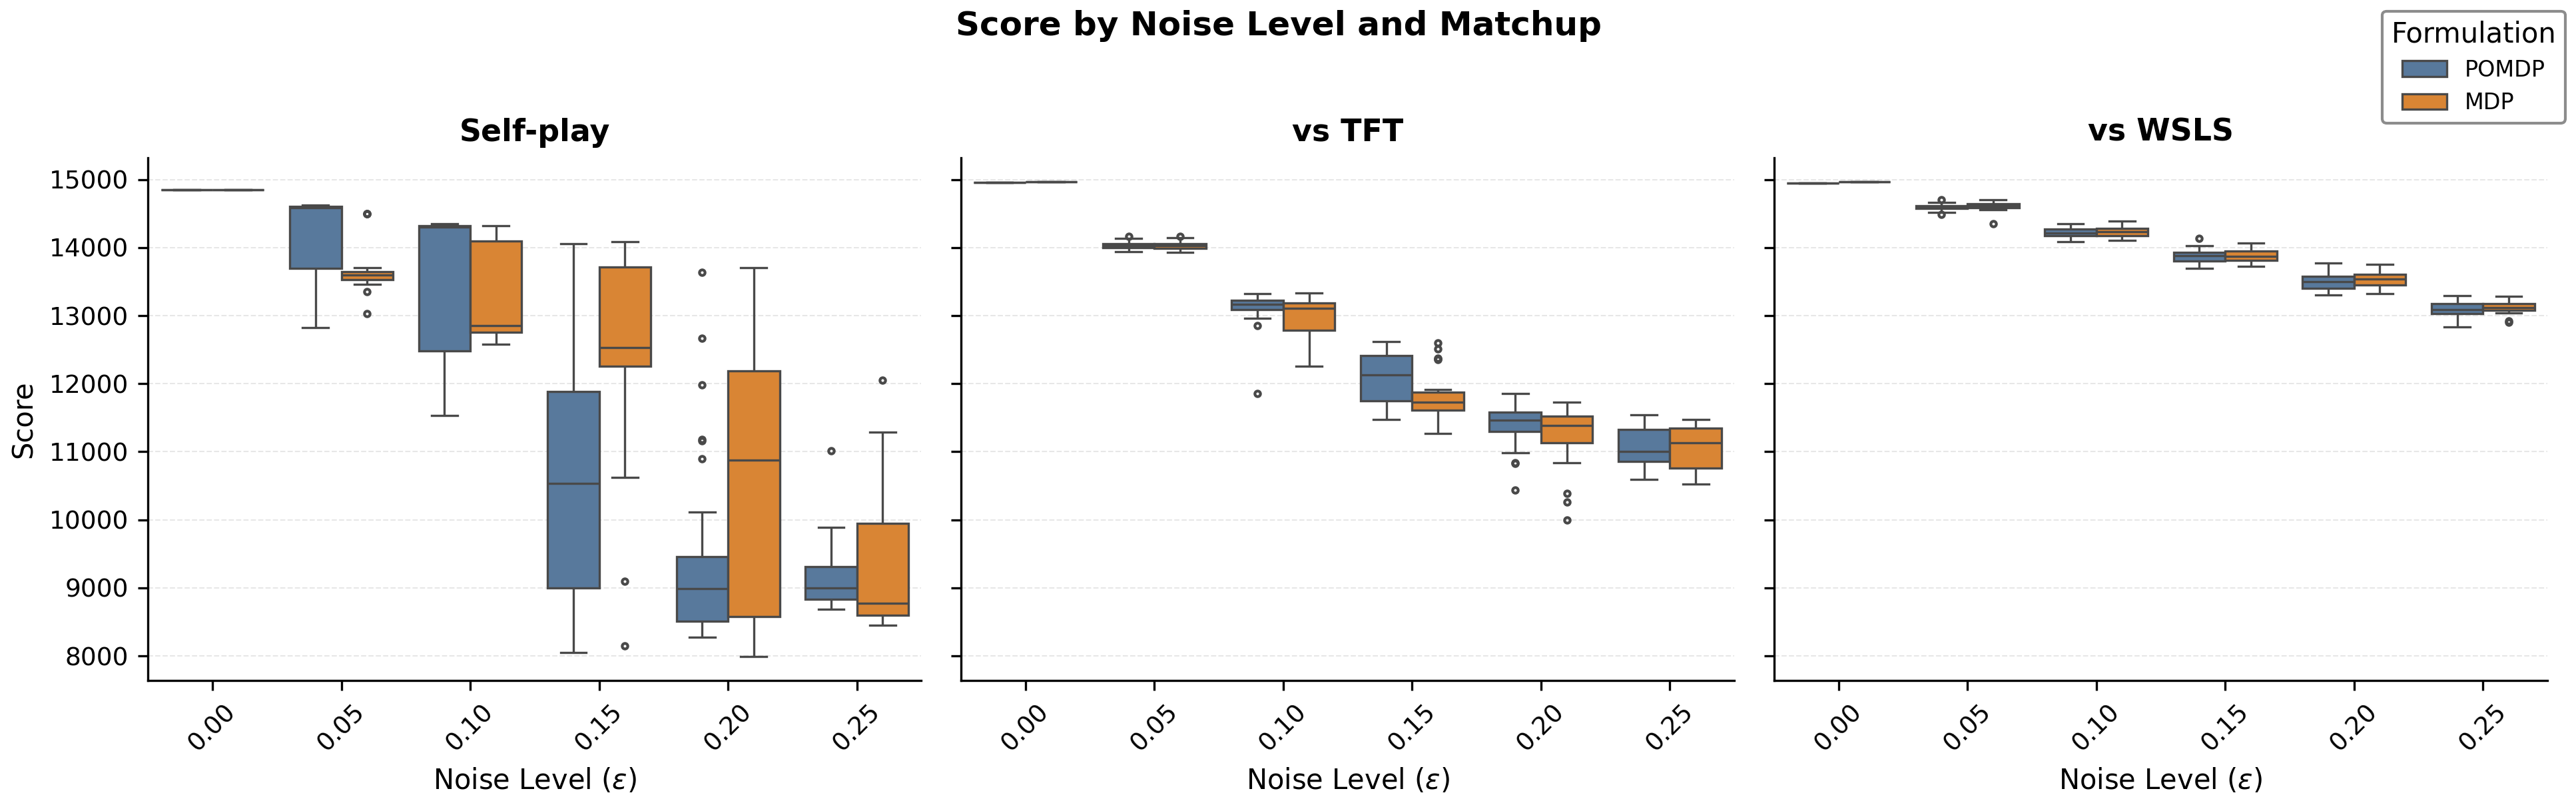

Saved: score_boxplots.pdf / .png


In [14]:
MATCHUPS   = ["Self-play", "vs TFT", "vs WSLS"]
HUE_ORDER  = ["POMDP", "MDP"]
PALETTE    = {"POMDP": "#4C78A8", "MDP": "#F58518"}
NOISE_ORDER = sorted(df["noise_label"].unique())

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, matchup in zip(axes, MATCHUPS):
    subset = df[df["matchup"] == matchup]
    sns.boxplot(
        data=subset,
        x="noise_label", y="score",
        hue="formulation", hue_order=HUE_ORDER,
        order=NOISE_ORDER,
        palette=PALETTE,
        linewidth=0.8, fliersize=2,
        ax=ax,
    )
    ax.set_title(matchup, fontweight="bold")
    ax.set_xlabel(r"Noise Level ($\epsilon$)")
    ax.tick_params(axis="x", rotation=45)
    ax.get_legend().remove()
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Score")
for ax in axes[1:]:
    ax.set_ylabel("")

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Formulation", loc="upper right",
           frameon=True, framealpha=0.9, edgecolor="gray")

fig.suptitle("Score by Noise Level and Matchup", y=1.02, fontweight="bold")
plt.tight_layout()

for fmt in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"score_boxplots.{fmt}", dpi=600, bbox_inches="tight")
plt.show()
print("Saved: score_boxplots.pdf / .png")

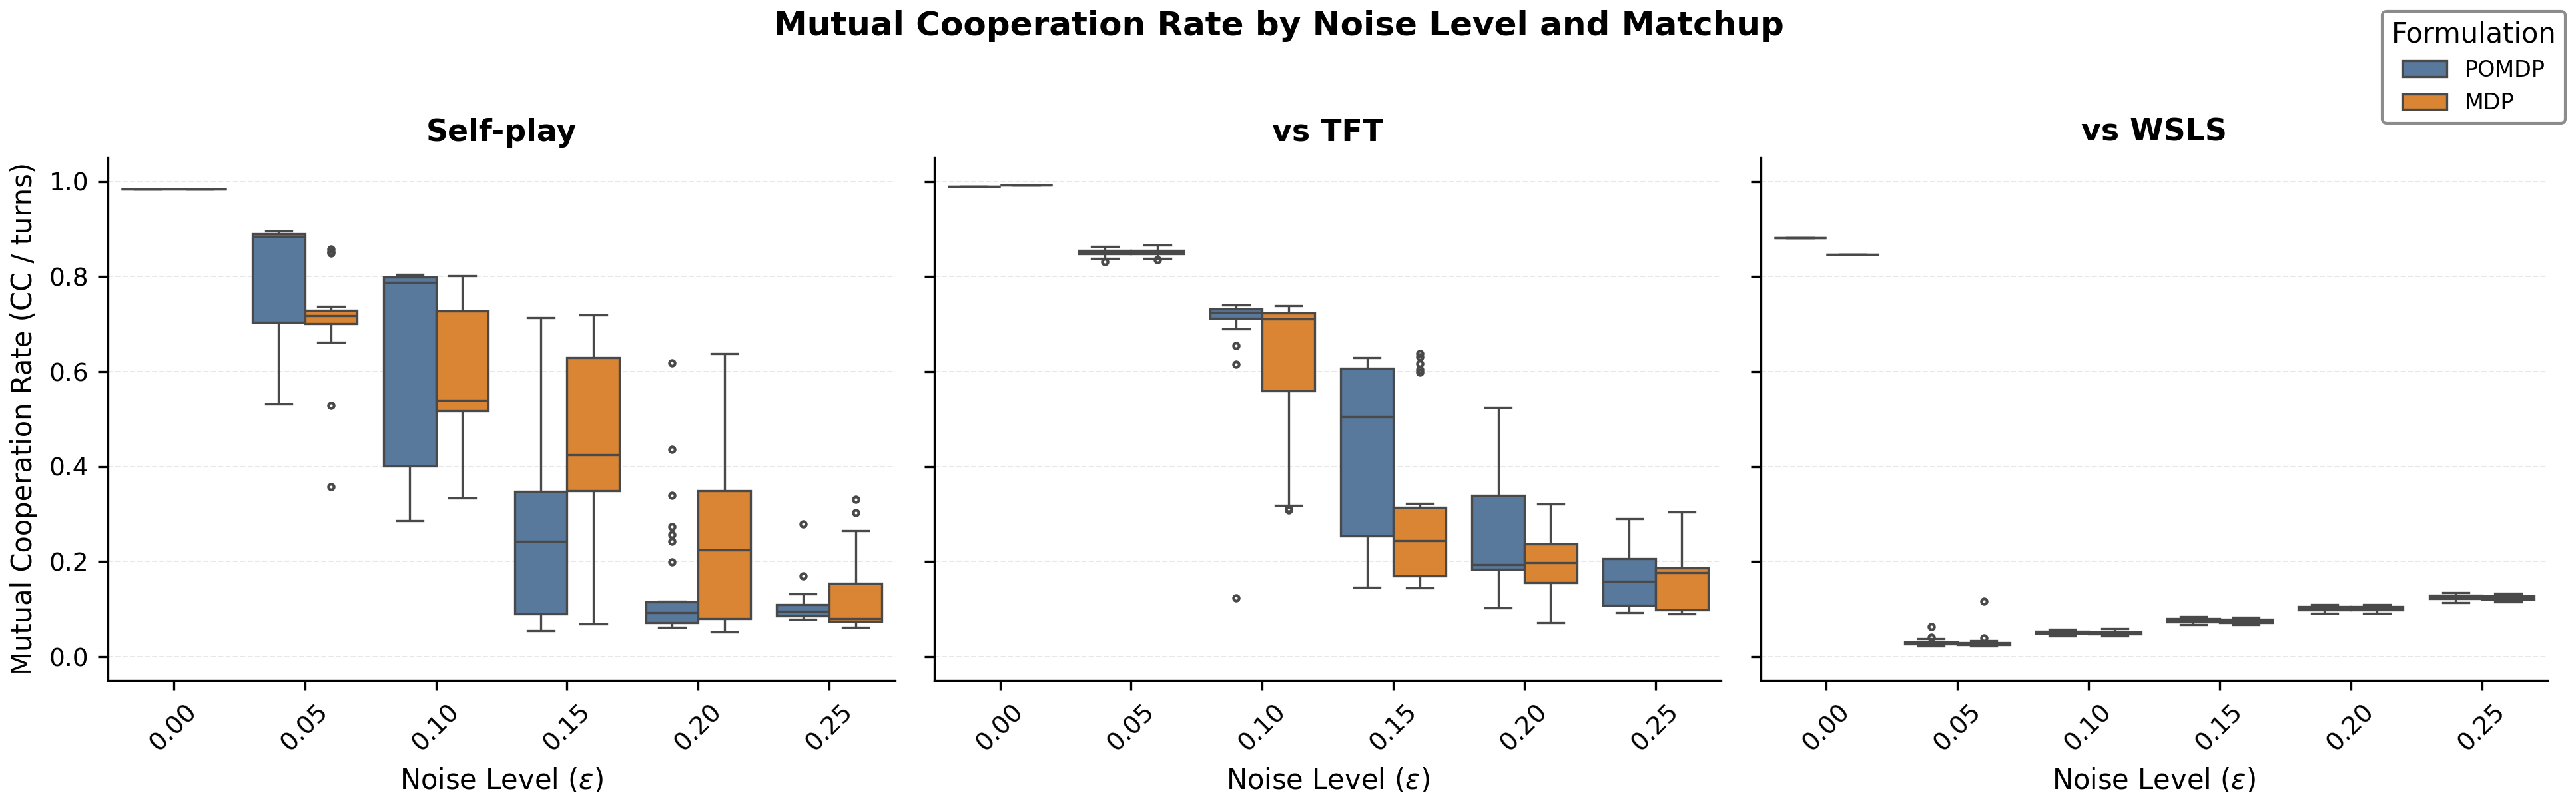

Saved: cc_rate_boxplots.pdf / .png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, matchup in zip(axes, MATCHUPS):
    subset = df[df["matchup"] == matchup]
    sns.boxplot(
        data=subset,
        x="noise_label", y="cc_rate",
        hue="formulation", hue_order=HUE_ORDER,
        order=NOISE_ORDER,
        palette=PALETTE,
        linewidth=0.8, fliersize=2,
        ax=ax,
    )
    ax.set_title(matchup, fontweight="bold")
    ax.set_xlabel(r"Noise Level ($\epsilon$)")
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="x", rotation=45)
    ax.get_legend().remove()
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Mutual Cooperation Rate (CC / turns)")
for ax in axes[1:]:
    ax.set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Formulation", loc="upper right",
           frameon=True, framealpha=0.9, edgecolor="gray")

fig.suptitle("Mutual Cooperation Rate by Noise Level and Matchup", y=1.02, fontweight="bold")
plt.tight_layout()

for fmt in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"cc_rate_boxplots.{fmt}", dpi=600, bbox_inches="tight")
plt.show()
print("Saved: cc_rate_boxplots.pdf / .png")

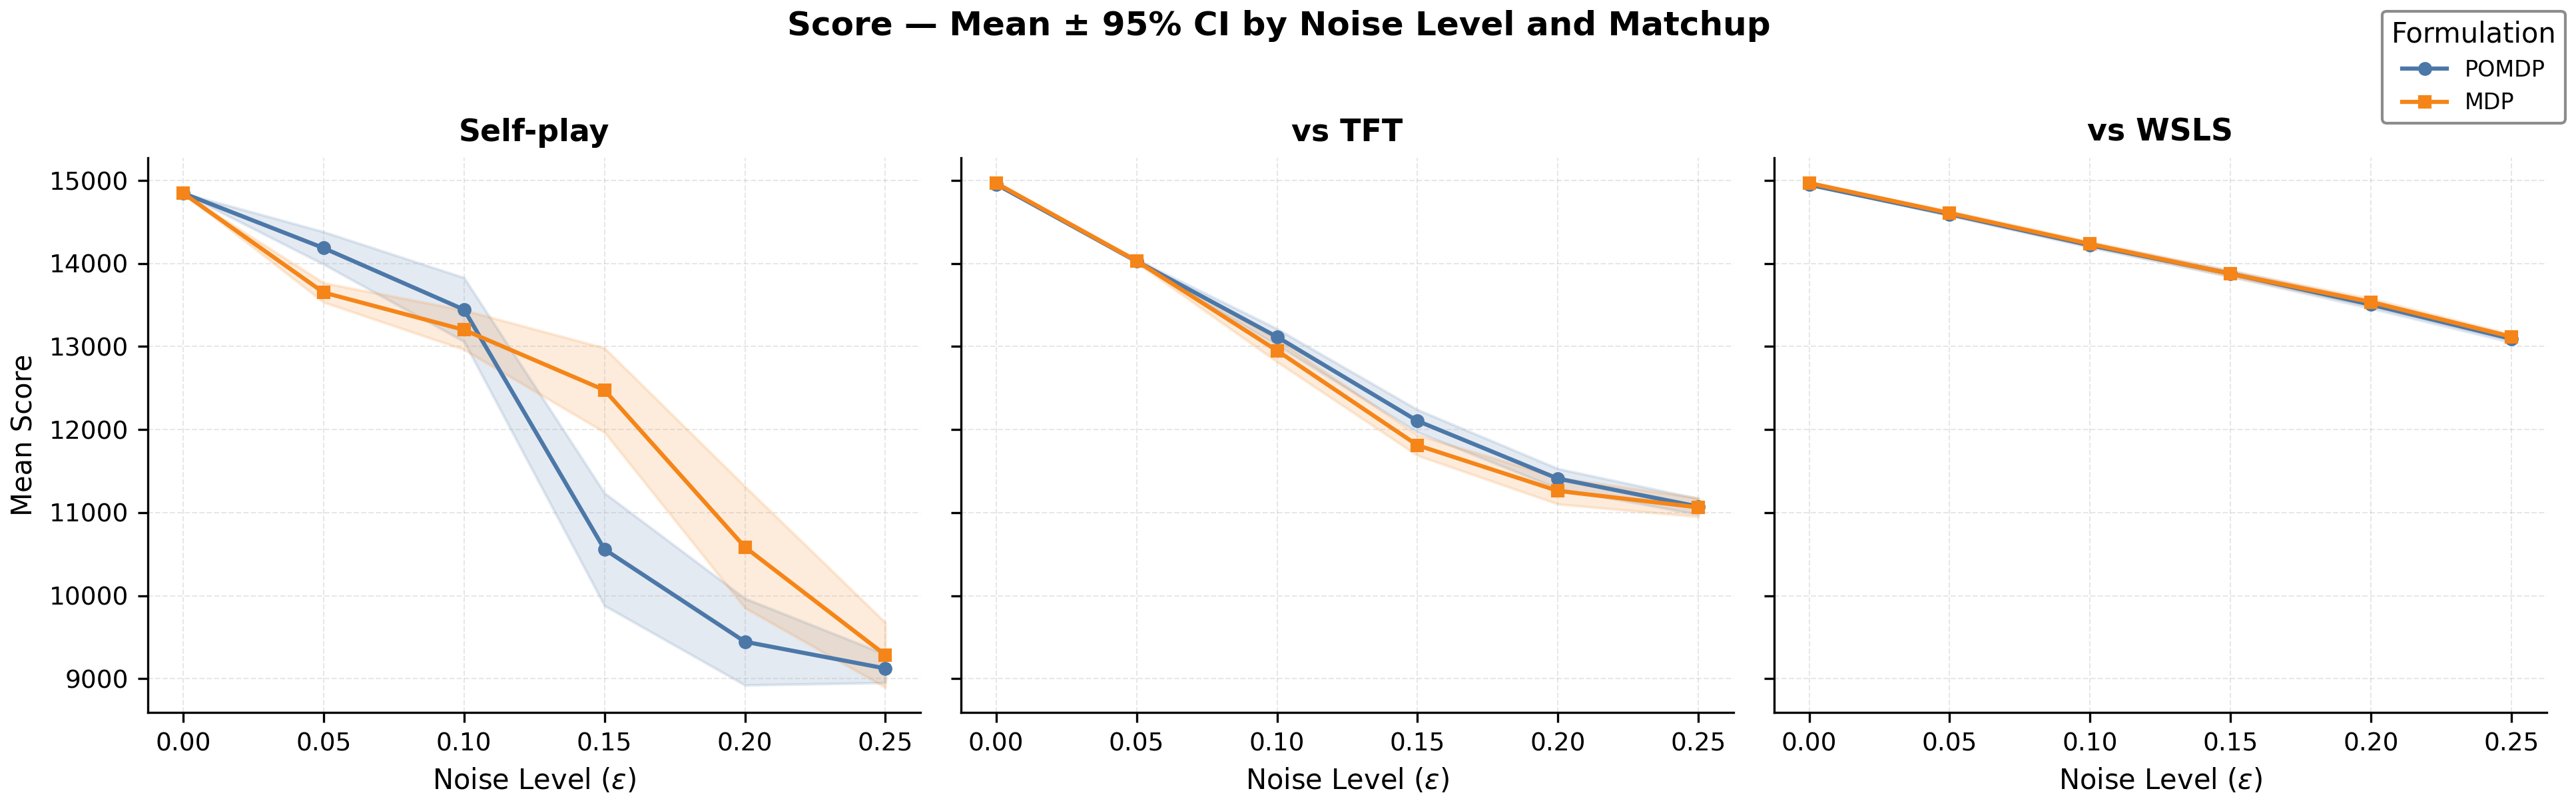

Saved: score_ci_lines.pdf / .png


In [16]:
from scipy import stats

def t_ci95(arr):
    """Return (mean, ci_lower, ci_upper) using a 95% t-interval."""
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = len(arr)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = float(np.mean(arr))
    if n == 1:
        return mean, mean, mean
    std = float(np.std(arr, ddof=1))
    if std <= 0 or not np.isfinite(std):
        return mean, mean, mean
    lo, hi = stats.t.interval(0.95, n - 1, loc=mean, scale=std / np.sqrt(n))
    return mean, float(lo), float(hi)


LINE_STYLE = {"POMDP": {"color": "#4C78A8", "marker": "o"},
              "MDP":   {"color": "#F58518", "marker": "s"}}


def plot_ci_lines(axes, metric, ylabel, ylim=None):
    noise_levels = sorted(df["noise_level"].unique())

    for ax, matchup in zip(axes, MATCHUPS):
        subset = df[df["matchup"] == matchup]
        for formulation in HUE_ORDER:
            s = subset[subset["formulation"] == formulation]
            nd = []
            for noise in noise_levels:
                vals = s.loc[s["noise_level"] == noise, metric].values
                mean, lo, hi = t_ci95(vals)
                nd.append({"noise": noise, "mean": mean, "lo": lo, "hi": hi})
            nd = pd.DataFrame(nd)
            style = LINE_STYLE[formulation]
            ax.plot(nd["noise"], nd["mean"],
                    marker=style["marker"], color=style["color"],
                    label=formulation, linewidth=1.5, markersize=4)
            ax.fill_between(nd["noise"], nd["lo"], nd["hi"],
                            alpha=0.15, color=style["color"])
        ax.set_title(matchup, fontweight="bold")
        ax.set_xlabel(r"Noise Level ($\epsilon$)")
        ax.grid(True, linestyle="--", alpha=0.3)
        if ylim is not None:
            ax.set_ylim(ylim)

    axes[0].set_ylabel(ylabel)
    for ax in axes[1:]:
        ax.set_ylabel("")
    handles, labels = axes[0].get_legend_handles_labels()
    return handles, labels


# ── Score mean ± 95% CI ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
handles, labels = plot_ci_lines(axes, "score", "Mean Score")
fig.legend(handles, labels, title="Formulation", loc="upper right",
           frameon=True, framealpha=0.9, edgecolor="gray")
fig.suptitle("Score — Mean ± 95% CI by Noise Level and Matchup", y=1.02, fontweight="bold")
plt.tight_layout()
for fmt in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"score_ci_lines.{fmt}", dpi=600, bbox_inches="tight")
plt.show()
print("Saved: score_ci_lines.pdf / .png")

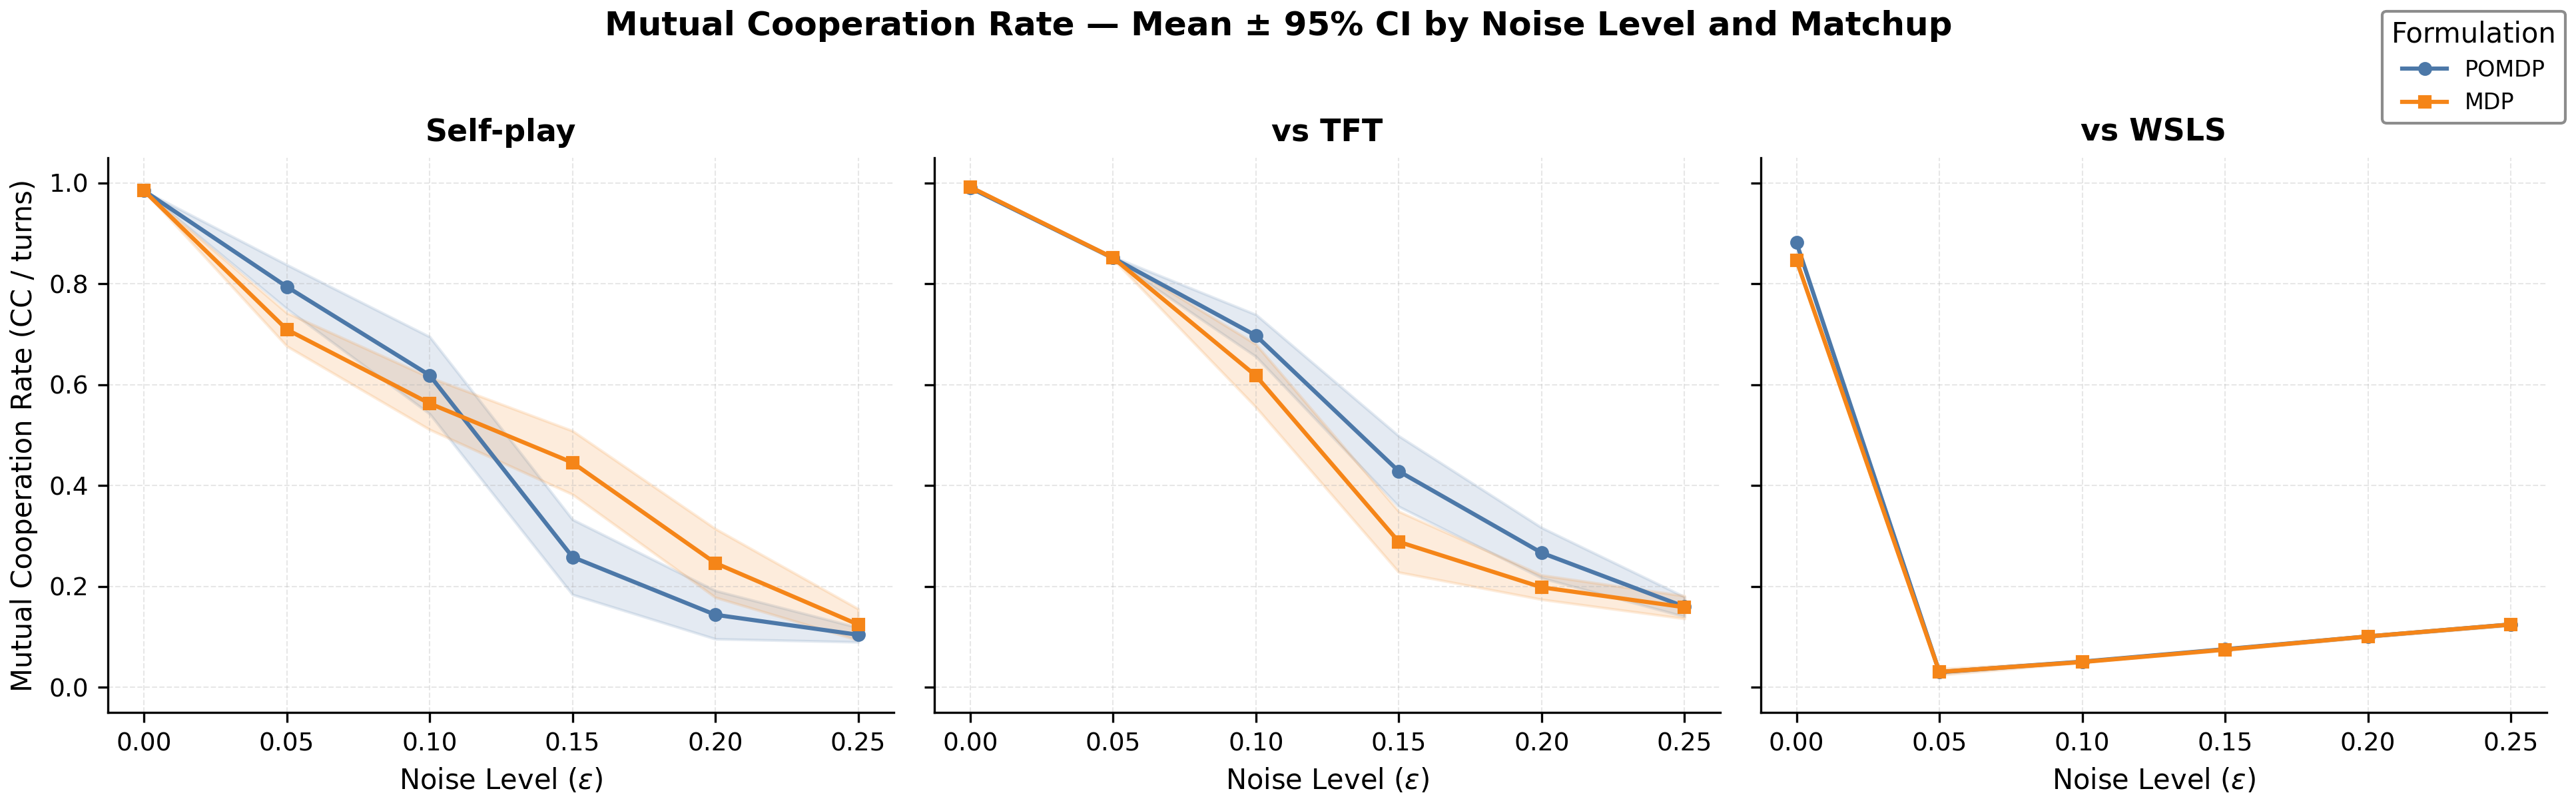

Saved: cc_rate_ci_lines.pdf / .png


In [17]:
# ── CC rate mean ± 95% CI ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
handles, labels = plot_ci_lines(axes, "cc_rate",
                                "Mutual Cooperation Rate (CC / turns)",
                                ylim=(-0.05, 1.05))
fig.legend(handles, labels, title="Formulation", loc="upper right",
           frameon=True, framealpha=0.9, edgecolor="gray")
fig.suptitle("Mutual Cooperation Rate — Mean ± 95% CI by Noise Level and Matchup",
             y=1.02, fontweight="bold")
plt.tight_layout()
for fmt in ("pdf", "png"):
    plt.savefig(OUTPUT_DIR / f"cc_rate_ci_lines.{fmt}", dpi=600, bbox_inches="tight")
plt.show()
print("Saved: cc_rate_ci_lines.pdf / .png")